In [5]:
# Cell 1 — environment setup (run first, once)
# %pip install -q scikit-learn==1.5.2 pandas==2.2.* matplotlib==3.8.*

Imports all packages
Load the dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path

np.random.seed(42)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(Path(path) / "loan_approval_dataset.csv")

## NASA Near-Earth Objects: clean and explore

*Drafted with Claude (AI-assisted). The cleaning choices below are proposals to confirm, not settled decisions.*

Each row is one observation of an asteroid; the same asteroid can appear in many rows. Target: `hazardous` (whether the asteroid is flagged potentially hazardous). The file was renamed from `neo_v2.csv` to `nasa_near_earth_objects.csv`.

### Clean

Checks run, and what each led to:

- **Missing values, exact duplicate rows:** checked; nothing to remove.
- **`name`:** dropped. It is a 1:1 label for `id`, so it adds nothing.
- **Constant columns** (`orbiting_body`, `sentry_object`): dropped. One value in every row carries no information.
- **Physical sanity checks** (diameters, velocity, miss distance all positive; max diameter >= min diameter): all pass, nothing to remove.
- **Outliers:** kept on purpose. The extreme diameters look like genuinely large asteroids rather than errors, and the heavy skew is a feature-building question, not a cleaning one.
- **`hazardous`:** converted from True/False to 0/1.
- **`id`:** kept, but it is not a feature. It is needed to split by asteroid (see the note below the cell).

In [2]:
df_neo = df.copy()

# 1. Missing values and exact duplicate rows
print("Missing values per column:")
print(df_neo.isna().sum().to_string())
print(f"\nExact duplicate rows: {df_neo.duplicated().sum()}")

# 2. `name` is a second label for the same object as `id` (one name per id), so it is redundant.
#    `id` stays: it identifies the asteroid and is needed to split by asteroid later. It is NOT a feature.
assert df_neo.groupby("id")["name"].nunique().max() == 1
df_neo = df_neo.drop(columns=["name"])

# 3. Constant columns have zero variance, so they cannot help any model.
constant_cols = [c for c in df_neo.columns if df_neo[c].nunique() == 1]
dropped = {c: df_neo[c].iloc[:1].tolist()[0] for c in constant_cols}
print(f"\nConstant columns dropped: {dropped}")
df_neo = df_neo.drop(columns=constant_cols)

# 4. Physical sanity checks. Any non-zero count would be a data error, so fail loudly.
violations = {
    "est_diameter_min <= 0": int((df_neo["est_diameter_min"] <= 0).sum()),
    "est_diameter_max < est_diameter_min": int((df_neo["est_diameter_max"] < df_neo["est_diameter_min"]).sum()),
    "relative_velocity <= 0": int((df_neo["relative_velocity"] <= 0).sum()),
    "miss_distance < 0": int((df_neo["miss_distance"] < 0).sum()),
}
print(f"\nInvalid-value checks: {violations}")
assert sum(violations.values()) == 0

# 5. Target as a 0/1 integer. (The +1/-1 SVM label convention is applied later, at model time.)
df_neo["hazardous"] = df_neo["hazardous"].astype(int)

# 6. Repeated observations: a row is one observation, not one unique asteroid.
rows_per_id = df_neo["id"].value_counts()
label_conflicts = int((df_neo.groupby("id")["hazardous"].nunique() > 1).sum())
print(f"\nRows: {len(df_neo):,} | unique asteroids: {rows_per_id.size:,} | "
      f"asteroids with >1 row: {(rows_per_id > 1).sum():,} | max rows for one asteroid: {rows_per_id.max()}")
print(f"Asteroids whose rows disagree on the label: {label_conflicts}")

print(f"\nCleaned shape: {df_neo.shape}")
print(df_neo.dtypes.to_string())

Missing values per column:
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0

Exact duplicate rows: 0

Constant columns dropped: {'orbiting_body': 'Earth', 'sentry_object': False}

Invalid-value checks: {'est_diameter_min <= 0': 0, 'est_diameter_max < est_diameter_min': 0, 'relative_velocity <= 0': 0, 'miss_distance < 0': 0}

Rows: 90,836 | unique asteroids: 27,423 | asteroids with >1 row: 15,902 | max rows for one asteroid: 43
Asteroids whose rows disagree on the label: 0

Cleaned shape: (90836, 7)
id                      int64
est_diameter_min      float64
est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
absolute_magnitude    float64
hazardous               int64


**Heads-up for the split step: rows are not independent.** The rows are repeated observations of the same asteroids (see the counts above), and an asteroid's label never changes between its rows. A random row-level split, or random 5-fold CV, would put the same asteroid in both train and test, so part of the score would just measure memorising asteroids already seen. The FAQ makes this point for grouped data: "split by group, because a random split puts the same subject on both sides and inflates the score." Splitting by `id` avoids it, and because the label is constant within an asteroid, stratifying at the asteroid level is well-defined.

In [3]:
feature_cols = ["est_diameter_min", "est_diameter_max", "relative_velocity", "miss_distance", "absolute_magnitude"]

summary = df_neo[feature_cols].describe().T
summary["skew"] = df_neo[feature_cols].skew()
summary

,count,mean,std,min,25%,50%,75%,max,skew
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,0.000609,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01,41.139952
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,0.001362,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01,41.139952
relative_velocity,90836.0,4.806692e+04,2.529330e+04,203.346432,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05,0.905125
miss_distance,90836.0,3.706655e+07,2.235204e+07,6745.532516,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07,-0.042706
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01,-0.137420


### Target distribution

Per row (observation):
           count   share
hazardous               
0          81996  0.9027
1           8840  0.0973
Imbalance ratio (0 : 1) = 9.3 : 1

Per unique asteroid:
           count   share
hazardous               
0          25250  0.9208
1           2173  0.0792


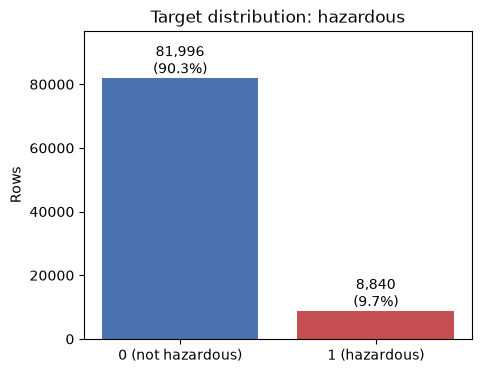

In [4]:
counts = df_neo["hazardous"].value_counts().sort_index()
share = counts / counts.sum()
print("Per row (observation):")
print(pd.DataFrame({"count": counts, "share": share.round(4)}).to_string())
print(f"Imbalance ratio (0 : 1) = {counts[0] / counts[1]:.1f} : 1")

# Hazardous asteroids average more rows each, so counting rows overstates their share.
# Count each asteroid once as well.
per_asteroid = df_neo.drop_duplicates("id")["hazardous"].value_counts().sort_index()
print("\nPer unique asteroid:")
print(pd.DataFrame({"count": per_asteroid, "share": (per_asteroid / per_asteroid.sum()).round(4)}).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["0 (not hazardous)", "1 (hazardous)"], counts.values, color=["#4C72B0", "#C44E52"])
for bar, n, s in zip(bars, counts.values, share.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{n:,}\n({s:.1%})", ha="center", va="bottom")
ax.set_ylabel("Rows")
ax.set_title("Target distribution: hazardous")
ax.set_ylim(0, counts.max() * 1.18)
plt.show()

### Pearson correlation matrix

Pearson measures *linear* association only, so a strong non-linear relationship can look weak here.

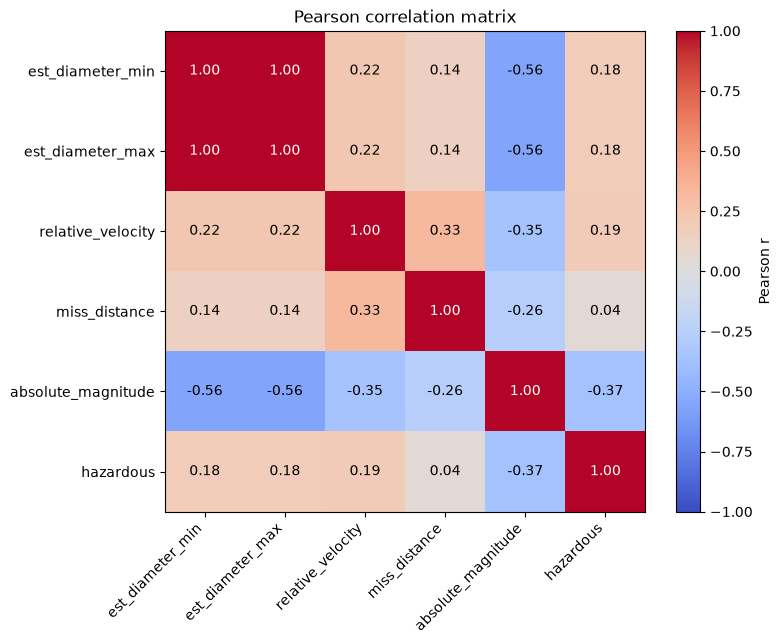

Correlation with the target (hazardous), sorted by |r|:
absolute_magnitude   -0.365
relative_velocity     0.191
est_diameter_max      0.183
est_diameter_min      0.183
miss_distance         0.042


In [5]:
corr_cols = feature_cols + ["hazardous"]
corr = df_neo[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), labels=corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), labels=corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

print("Correlation with the target (hazardous), sorted by |r|:")
print(corr["hazardous"].drop("hazardous").sort_values(key=abs, ascending=False).round(3).to_string())

Pre process the data

In [53]:
X = df[["variance","skewness","curtosis", "entropy"]].to_numpy()
y = 2 * df["class"].to_numpy() - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
X_train_std = (X_train - mu) / sigma
X_test_std = (X_test - mu) / sigma

print(f"Train: {X_train_std.shape}, Test: {X_test_std.shape}")
print(f"Train label balance: {np.mean(y_train == 1):.3f} positive")

Train: (1097, 4), Test: (275, 4)
Train label balance: 0.445 positive


Function to compute the loss and the gradient
Loss: how much difference the prediction is from the target
in this case since this is classification, we only care how bad the misclassification is
Gradient: how much should we update the weights wrt to the loss

In [54]:
def compute_loss(w, b, X, y, C):
    margins = y * (X @ w + b)
    xi = np.maximum(0, 1 - margins)
    return 0.5 * (w @ w) + C * np.mean(xi)

In [ ]:
def train_svm(X, y, C=100.0, lr=3e-5, epochs=10):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    loss_history = []
    for _ in range(epochs):
        for i in np.random.permutation(n):
            x_i, y_i = X[i], y[i]

            # 1. Check margin condition: y_i * (w @ x_i + b) >= 1
            condition = y_i * (x_i @ w + b) >= 1

            # 2. Apply subgradient update
            if condition:
                w -= lr * w
            else:
                w -= lr * (w - C * y_i * x_i)
                b += lr * C * y_i

        loss_history.append(compute_loss(w, b, X, y, C))

    return w, b, loss_history

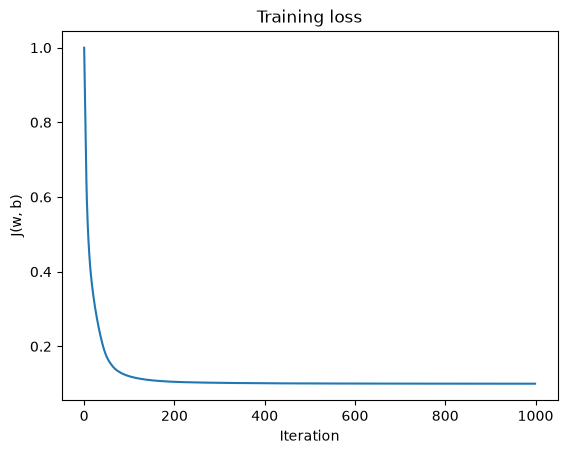

Final loss: 0.0999
w = [-1.60109269 -1.7031238  -1.54346538  0.11462317], b = -0.3328


In [56]:
w, b, loss_history = train_svm(X_train_std, y_train, C=100.0, lr=3e-5, epochs=10)

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("J(w, b)")
plt.title("Training loss")
plt.show()

print(f"Final loss: {loss_history[-1]:.4f}")
print(f"w = {w}, b = {b:.4f}")

In [57]:
def predict(w, b, X):
    return np.sign(X @ w + b)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [58]:
train_preds = predict(w, b, X_train_std)
test_preds = predict(w, b, X_test_std)

train_acc = accuracy(y_train, train_preds)
test_acc = accuracy(y_test, test_preds)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Train accuracy: 0.9854
Test accuracy: 0.9709


In [59]:
def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == -1) & (y_pred == -1))
    fp = np.sum((y_true == -1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == -1))
    return np.array([[tn, fp], [fn, tp]])

cm = confusion_matrix(y_test, test_preds)
print(f"Confusion matrix (rows=true, cols=pred, order=[-1,+1]):\n{cm}")

Confusion matrix (rows=true, cols=pred, order=[-1,+1]):
[[145   8]
 [  0 122]]


lam=0.0001   train_acc=0.9854  test_acc=0.9709
lam=0.001    train_acc=0.9854  test_acc=0.9709
lam=0.01     train_acc=0.9854  test_acc=0.9709
lam=0.1      train_acc=0.9772  test_acc=0.9709
lam=1.0      train_acc=0.8551  test_acc=0.8836
lam=10.0     train_acc=0.5552  test_acc=0.5564


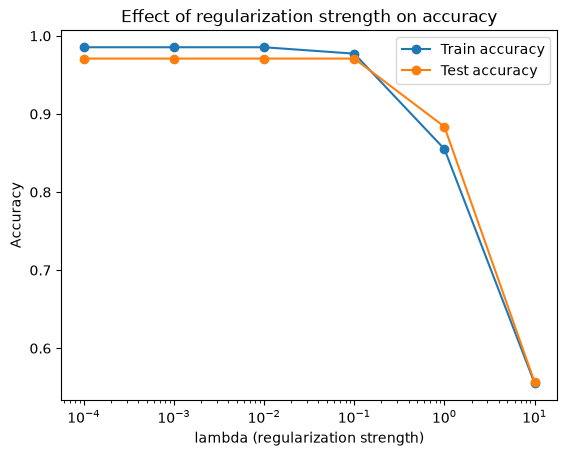

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\awils\\documents\\uts\\sem_2\\ada\\assignment_2\\venv\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp312-win_amd64.pyd'
Check the permissions.



In [60]:
C_values = [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
results = []

for C in C_values:
    # each violated row pulls w by lr * C, so lr is scaled by 1/C to keep that pull the same size for every C
    w_i, b_i, _ = train_svm(X_train_std, y_train, C=C, lr=0.003 / C, epochs=10)
    train_acc_i = accuracy(y_train, predict(w_i, b_i, X_train_std))
    test_acc_i = accuracy(y_test, predict(w_i, b_i, X_test_std))
    results.append((C, train_acc_i, test_acc_i))
    print(f"C={C:<8} train_acc={train_acc_i:.4f}  test_acc={test_acc_i:.4f}")

Cs, train_accs, test_accs = zip(*results)
plt.plot(Cs, train_accs, marker='o', label='Train accuracy')
plt.plot(Cs, test_accs, marker='o', label='Test accuracy')
plt.xscale('log')
plt.xlabel('C (penalty on margin violations)')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Effect of regularization strength on accuracy')
plt.show()